In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"

In [29]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

num_cols = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time",
]
cat_cols = ["gender", "stress_level", "academic_work_impact"]

#### 결측 indicator 

결측은 Target과 관련이 약하다. 모델이 비선형적으로 반응할 가능성이 있다. 검증 목적으로만 만들어서 나중에 Feature Importance에서 실제로 하위권에 머무는지 확인

In [30]:
for col in num_cols + cat_cols:
    train[f"{col}_missing"] = train[col].isna().astype(int)
    test[f"{col}_missing"] = test[col].isna().astype(int)

train.filter(like="_missing").sum().sort_values(ascending=False)

social_media_hours_missing         133995
gaming_hours_missing               126821
weekend_screen_time_missing        112063
daily_screen_time_hours_missing     95854
app_opens_per_day_missing           80710
notifications_per_day_missing       67584
stress_level_missing                55148
work_study_hours_missing            51518
sleep_hours_missing                 44480
academic_work_impact_missing        44224
gender_missing                      29034
age_missing                         28929
dtype: int64

#### 결측치 대체
수치형은 중앙값, 범주형은 최빈값으로 채움

통계값은 train 기준으로 계산, test에 그대로 적용

In [31]:
num_medians = train[num_cols].median()
cat_modes = train[cat_cols].mode().iloc[0]

train[num_cols] = train[num_cols].fillna(num_medians)
test[num_cols] = test[num_cols].fillna(num_medians)

train[cat_cols] = train[cat_cols].fillna(cat_modes)
test[cat_cols] = test[cat_cols].fillna(cat_modes)

train[num_cols + cat_cols].isna().sum().sum(), test[num_cols + cat_cols].isna().sum().sum()

(0, 0)

#### 사용비율 or 조합 변수

daily_screen_time_hours와 social_media_hours는 각각 상관계수가 높음

둘 다 절대시간. "얼마나 오래 썼는가"를 나타낸다

Q. 하루 중 SNS에 얼마나 몰아서 쓰는가. 

같은 5시간이어도 그중 4시간이 SNS면 다른 이야기가 됨. 절대값 대신 비중을 새 변수로 만든다. 

In [32]:
def add_ratio_features(df):
    df = df.copy()
    df["social_gaming_hours"] = df["social_media_hours"] + df["gaming_hours"]
    df["social_media_ratio"] = df["social_media_hours"] / df["daily_screen_time_hours"].replace(0, np.nan)
    df["gaming_ratio"] = df["gaming_hours"] / df["daily_screen_time_hours"].replace(0, np.nan)
    df["weekend_weekday_gap"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    df["notif_per_app_open"] = df["notifications_per_day"] / df["app_opens_per_day"].replace(0, np.nan)
    df["screen_time_per_sleep"] = df["daily_screen_time_hours"] / df["sleep_hours"].replace(0, np.nan)
    return df

train = add_ratio_features(train)
test = add_ratio_features(test)

for col in ["social_media_ratio", "gaming_ratio", "weekend_weekday_gap", "screen_time_per_sleep"]:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

train[["social_media_ratio", "gaming_ratio", "weekend_weekday_gap", "screen_time_per_sleep"]].describe().T

,count,mean,std,min,25%,50%,75%,max
social_media_ratio,691369.0,0.329712,0.151197,0.000000,0.234685,0.312399,0.412935,4.620000
gaming_ratio,691369.0,0.196673,0.112161,0.000000,0.120573,0.182353,0.265550,2.660000
weekend_weekday_gap,691369.0,1.837328,1.979840,-7.910000,0.550000,1.810000,3.100000,11.490000
screen_time_per_sleep,691369.0,1.160670,0.439299,0.055679,0.857554,1.142647,1.438889,3.289474


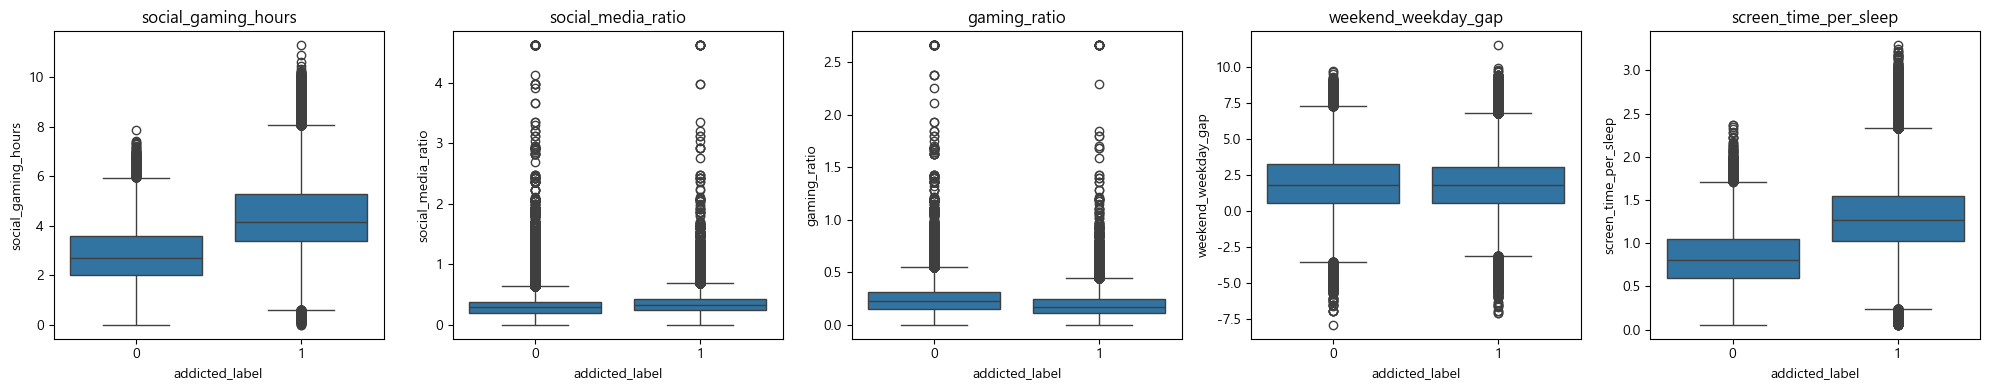

In [33]:
new_features = ["social_gaming_hours", "social_media_ratio", "gaming_ratio",
                 "weekend_weekday_gap", "screen_time_per_sleep"]

fig, axes = plt.subplots(1, len(new_features), figsize=(20, 4))
for ax, col in zip(axes, new_features):
    sns.boxplot(data=train, x="addicted_label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

social_media_ratio와 weekend_weekday_gap은 두 그룹의 중앙값이 눈에 띄게 벌어진다

"비중"과 "주말 증가폭" 자체도 신호로 사용가능하다. 

gaming_ratio는 분포가 거의 겹치다. 원본 gaming_hours보다 나은 신호는 아님. 모델에 넣을 때 gaming_Ratio를 우선순위 뒤로 미루는 근거가 됨

In [34]:
new_corr = train[new_features + ["addicted_label"]].corr()["addicted_label"].drop("addicted_label")
new_corr.sort_values(ascending=False)

social_gaming_hours      0.478929
screen_time_per_sleep    0.477013
social_media_ratio       0.106947
weekend_weekday_gap     -0.010931
gaming_ratio            -0.196662
Name: addicted_label, dtype: float64

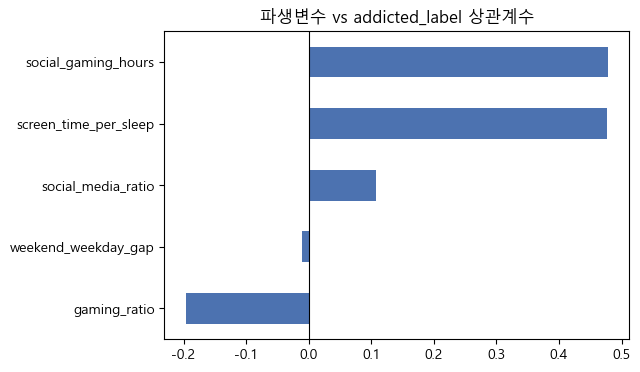

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
new_corr.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("파생변수 vs addicted_label 상관계수")
ax.axvline(0, color="black", linewidth=0.8)
plt.show()

#### 범주형 x 시간 변수
01_eda에서 stress_level 단독으로는 addicted_label과 거의 관련이 없었음 

"스트레스가 높은 사람이 화면을 오래 보는 것"과 "스트레스가 낮은
사람이 화면을 오래 보는 것"이 같은 의미일 필요는 없음

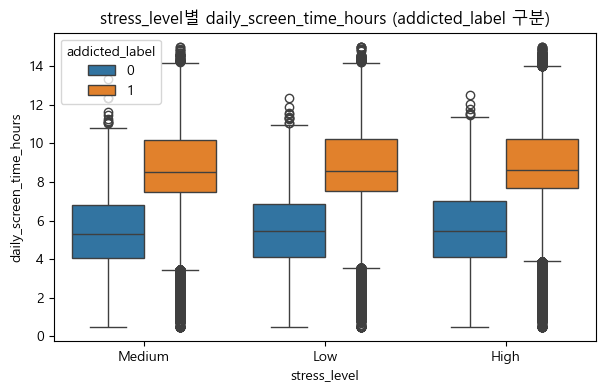

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train, x="stress_level", y="daily_screen_time_hours", hue="addicted_label", ax=ax)
ax.set_title("stress_level별 daily_screen_time_hours (addicted_label 구분)")
plt.show()

#### Target Encoding 범주형 변수
gender, stress_level, academic_work_impact는 One-Hot보다 Target Encoding이 정보량 면에서 유리하다. 그대로 계산하면 train 정보가 새서
과적합으로 이어진다. 

In [37]:
from sklearn.model_selection import StratifiedKFold

def target_encode_kfold(train, test, col, target="addicted_label", n_splits=5, seed=42):
    train = train.copy()
    test = test.copy()
    oof = np.zeros(len(train))
    global_mean = train[target].mean()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in skf.split(train, train[target]):
        means = train.iloc[tr_idx].groupby(col)[target].mean()
        oof[val_idx] = train.iloc[val_idx][col].map(means).fillna(global_mean)

    train[f"{col}_te"] = oof
    full_means = train.groupby(col)[target].mean()
    test[f"{col}_te"] = test[col].map(full_means).fillna(global_mean)
    return train, test

for col in cat_cols:
    train, test = target_encode_kfold(train, test, col)

train[[f"{c}_te" for c in cat_cols]].describe().T

,count,mean,std,min,25%,50%,75%,max
gender_te,691369.0,0.709424,0.009273,0.700602,0.701201,0.703908,0.721486,0.722087
stress_level_te,691369.0,0.709424,0.002481,0.705342,0.706173,0.710806,0.711096,0.711651
academic_work_impact_te,691369.0,0.709425,0.001504,0.707772,0.708051,0.708528,0.711052,0.711382


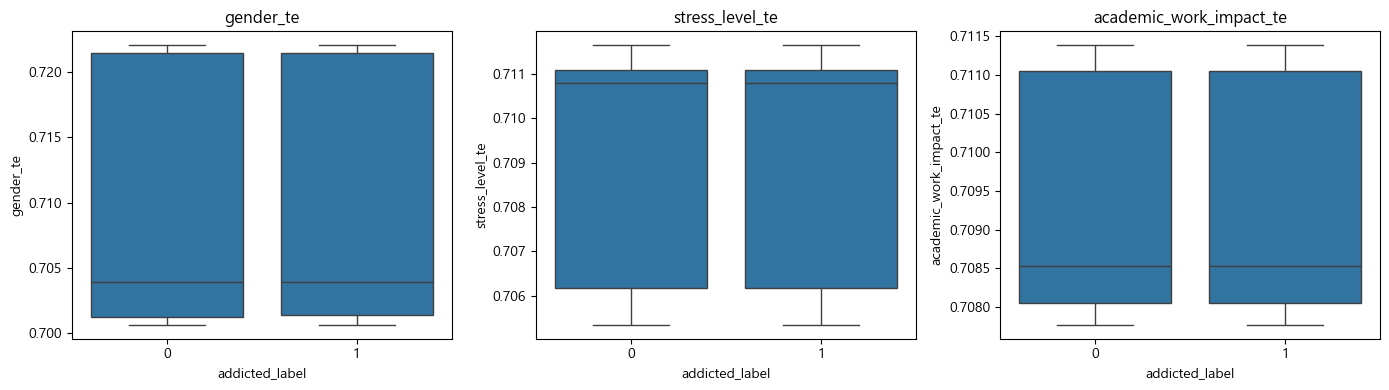

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=train, x="addicted_label", y=f"{col}_te", ax=ax)
    ax.set_title(f"{col}_te")
plt.tight_layout()
plt.show()

In [39]:
train.to_csv("../data/train_fe.csv", index=False)
test.to_csv("../data/test_fe.csv", index=False)

핵심: daily_screen_time_hours, weekend_screen_time, social_media_hours,
      social_gaming_hours, screen_time_per_sleep

보조/재검토: social_media_ratio (양의 방향, 약함)

제외 후보: weekend_weekday_gap (거의 0)

역방향 확인 필요: gaming_ratio (음의 상관, -0.19)